In [1]:
import pymcel as pc

Bienvenido a PyMCel v0.9.10 ¡al infinito y más allá!


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [2]:
sistema = [
    dict(m=1, r = [0,0,0], v = [0,0,0]),
    dict(m=1, r = [1,0,0], v = [0,1,0]) 
]

In [6]:
ts = np.linspace(0, 10, 1000)
rs, vs, rps, vps, constantes = pc.ncuerpos_solucion(sistema, ts)

In [7]:
rs.shape

(2, 1000, 3)

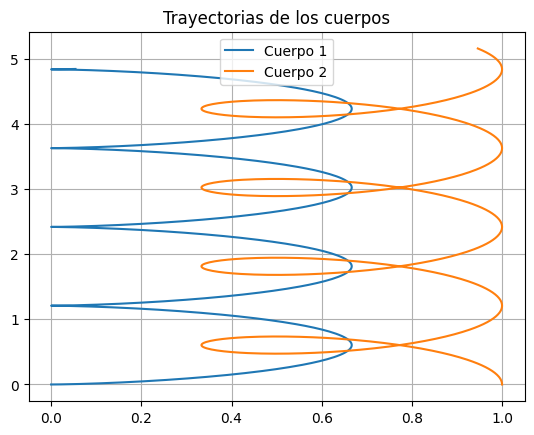

In [12]:
plt.plot(rs[0,:,0], rs[0,:,1],label='Cuerpo 1')
plt.plot(rs[1,:,0], rs[1,:,1],label='Cuerpo 2')
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.grid()
plt.show()


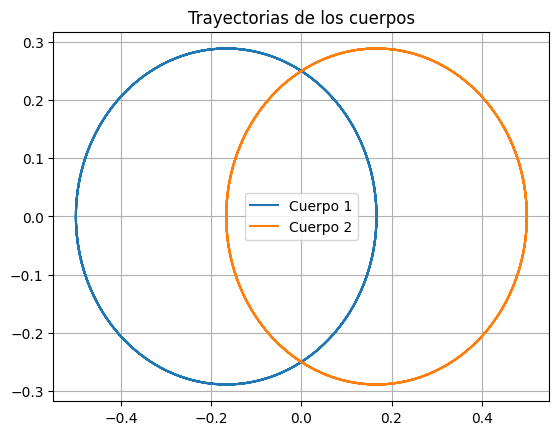

In [13]:
plt.plot(rps[0,:,0], rps[0,:,1],label='Cuerpo 1')
plt.plot(rps[1,:,0], rps[1,:,1],label='Cuerpo 2')
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.grid()
plt.show()

## Cuadraturas
### Momentum lineal total

In [16]:
suma = 0
for i in range(2):
    suma += sistema[i]['m']*vs[i,42,:]

suma

array([0., 1., 0.])

In [18]:
sistema[0]['m']*vs[0] + sistema[1]['m']*vs[1]

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       ...,
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.]], shape=(1000, 3))

### Momentum angular total

In [17]:
suma = 0
for i in range(2):
    suma += sistema[i]['m']*np.cross(rs[i,50,:], vs[i,50,:])

suma

array([0.        , 0.        , 0.99999995])

In [19]:
suma = np.sum(np.cross(rs[:, 50, :], vs[:, 50, :], axis=1) * np.array([c['m'] for c in sistema])[:, None], axis=0)